In [2]:
import pandas as pd
import numpy as np

import os
import tarfile
from six.moves import urllib
import pandas as pd

# Константы для путей и URL
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH = os.path.join("../../datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    """Скачивает архив данных, распаковывает его и сохраняет в локальный каталог."""
    # Если папки для данных нет, создаем её
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)

    tgz_path = os.path.join(housing_path, "housing.tgz")

    # Загружаем архив по URL
    urllib.request.urlretrieve(housing_url, tgz_path)

    # Распаковываем tgz-архив
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

def load_housing_data(housing_path=HOUSING_PATH):
    """Считывает распакованный CSV-файл и возвращает объект DataFrame."""
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

# ==========================================
# Пример запуска:
# ==========================================
if __name__ == "__main__":
    # 1. Скачиваем и распаковываем файлы (нужно запустить один раз)
    print("Загрузка данных...")
    fetch_housing_data()

    # 2. Загружаем данные в DataFrame
    print("Чтение данных в Pandas...")
    housing = load_housing_data()


Загрузка данных...
Чтение данных в Pandas...


C:\Users\Vlad\AppData\Local\Temp\ipykernel_20616\3144637967.py:27: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


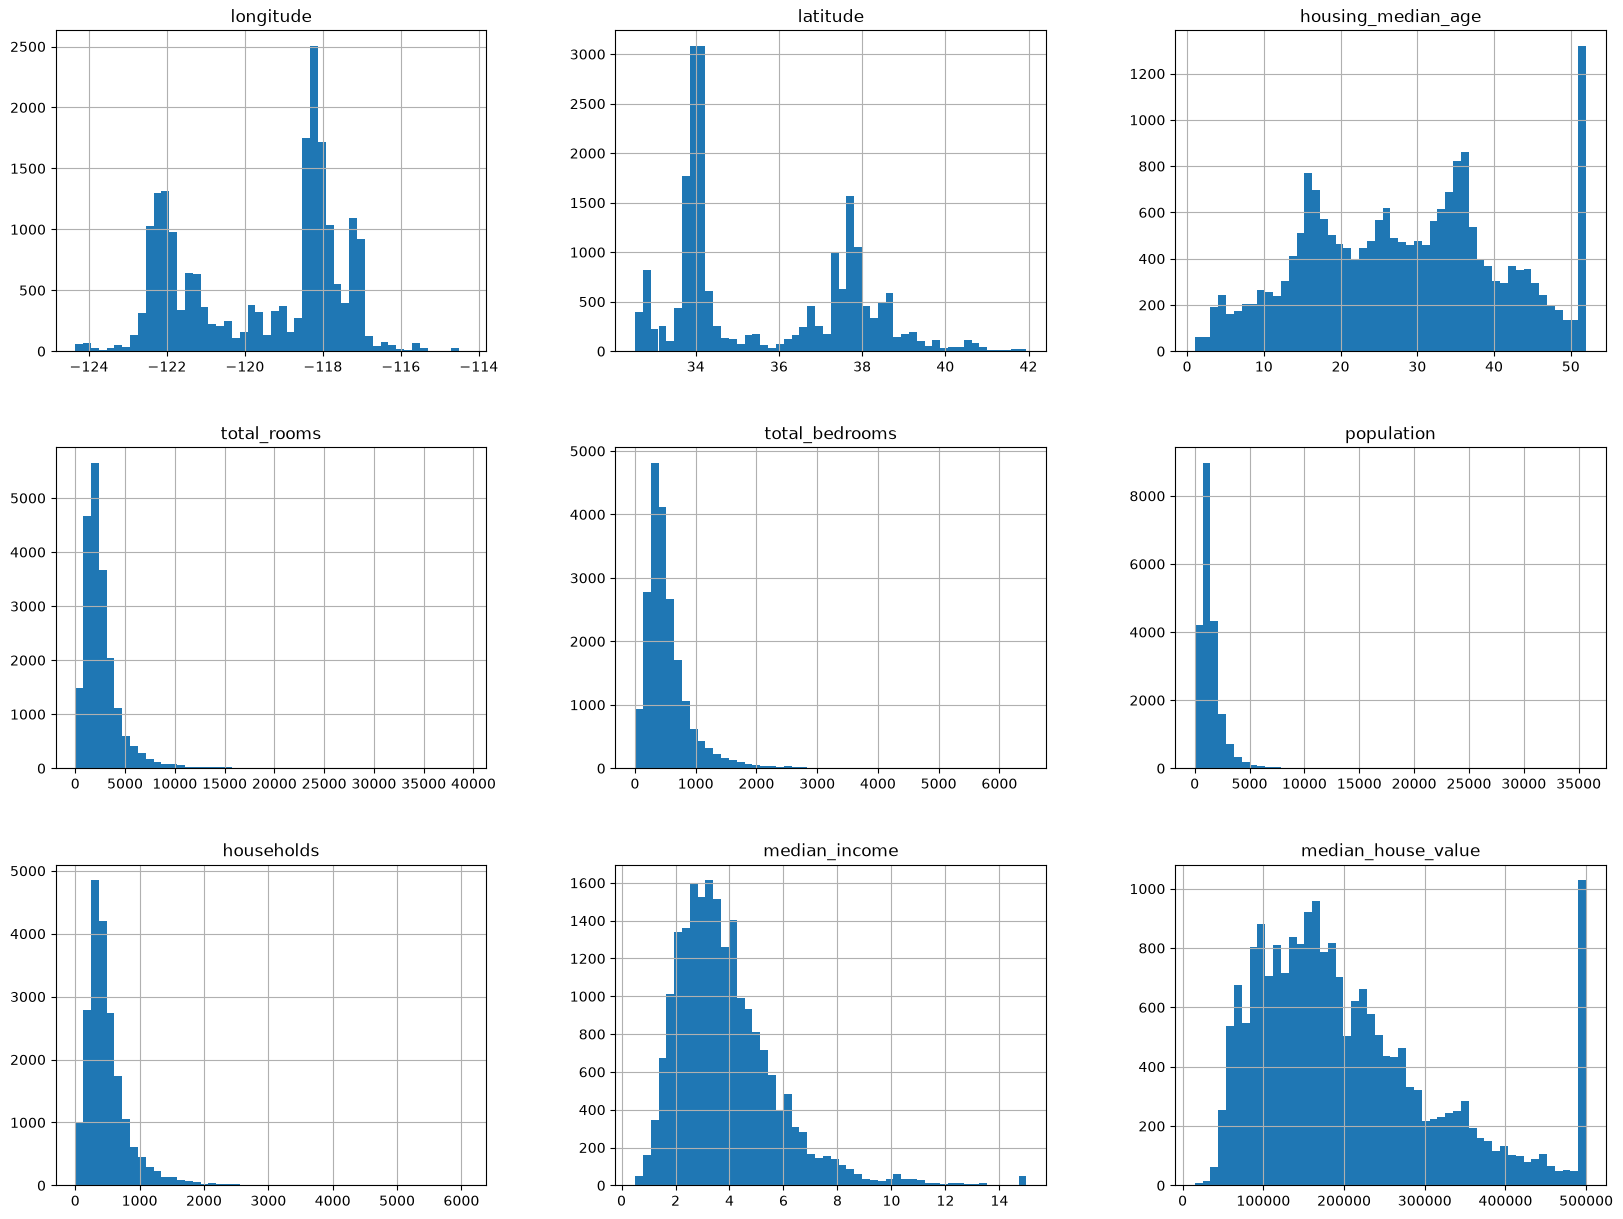

In [7]:
import matplotlib.pyplot as plt
plt.style.use('default')
housing.hist(bins=50, figsize=(20, 15))
plt.show()


<Axes: >

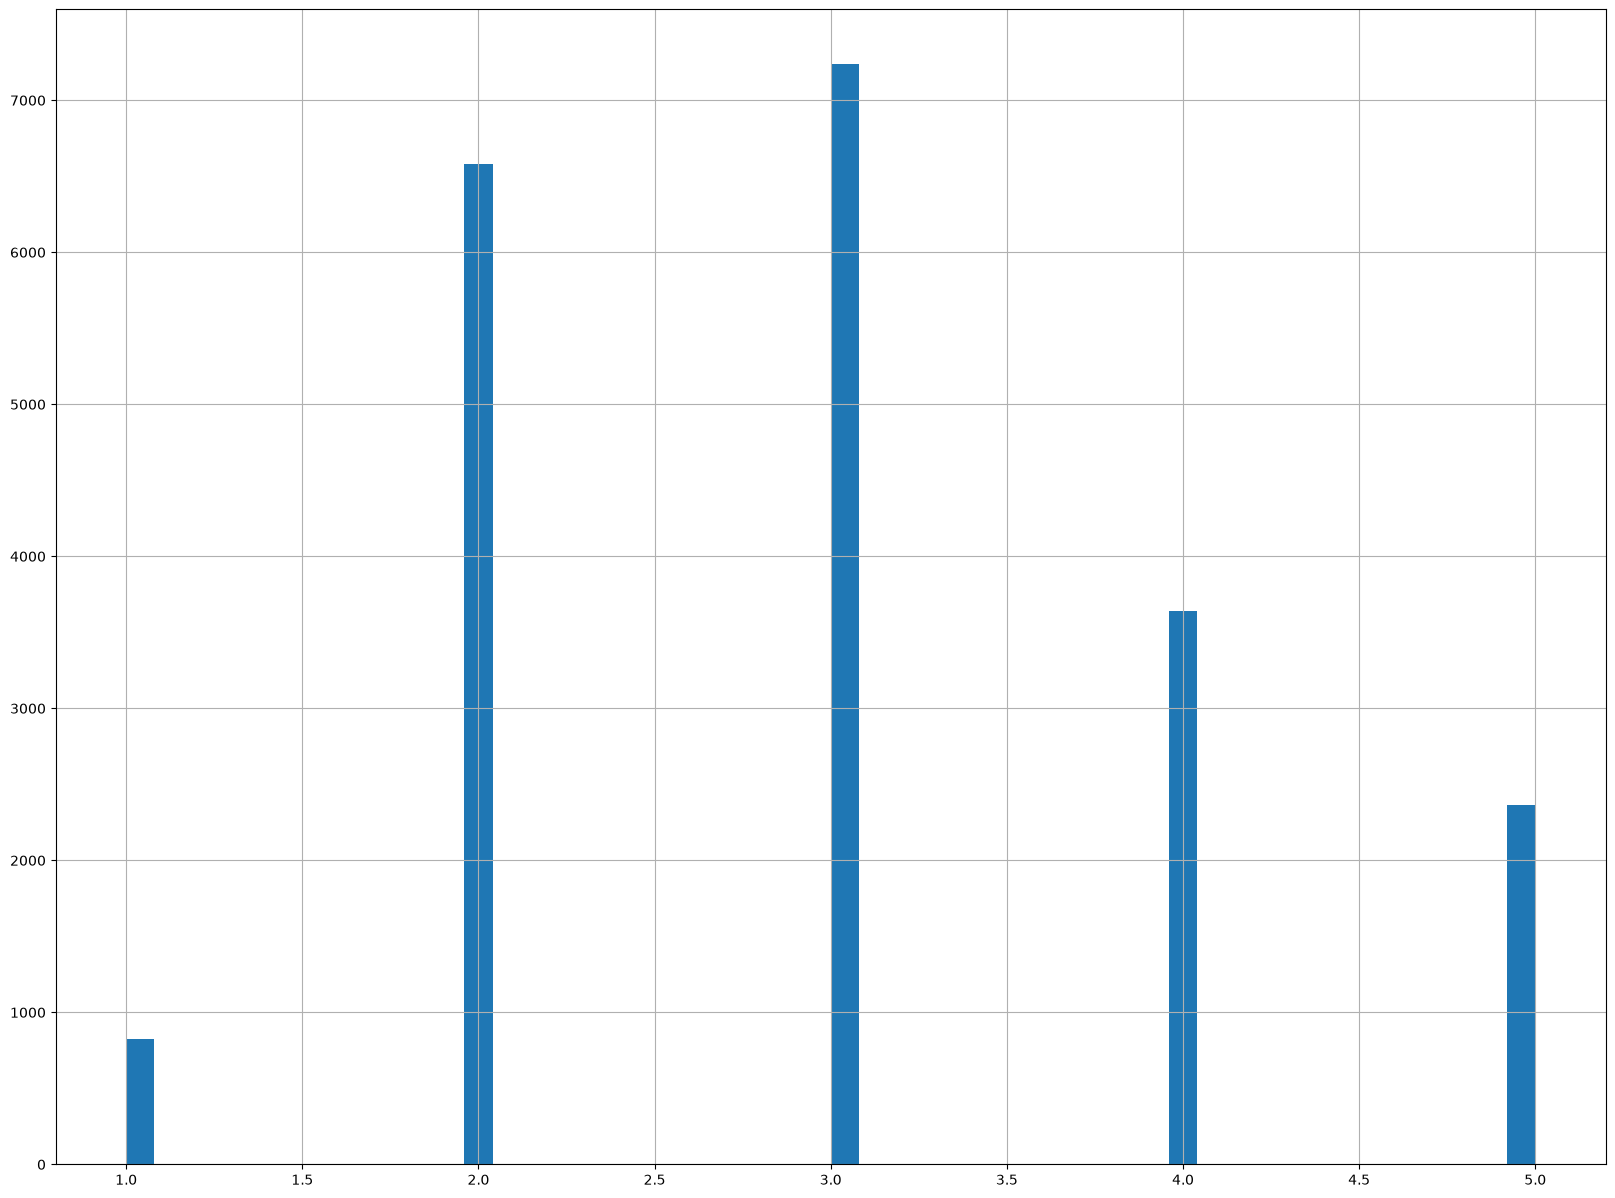

In [8]:
housing['income_cat'] = np.ceil(housing['median_income'] / 1.5)
housing['income_cat'] = housing['income_cat'].where(housing['income_cat'] < 5, 5)
housing['income_cat'].hist(bins=50, figsize=(20, 15))

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit


split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing['income_cat']):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

strat_train_set = strat_train_set.drop("income_cat", axis=1)
strat_test_set = strat_test_set.drop("income_cat", axis=1)


In [10]:
housing = strat_train_set.copy()

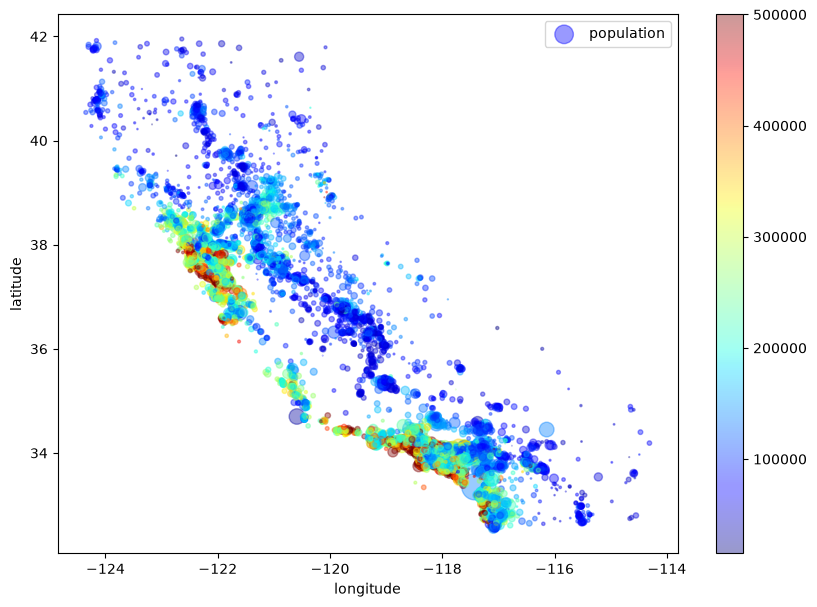

In [11]:
housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.4, s=housing['population']/100, label='population', figsize=(10, 7),
             c=housing['median_house_value'], cmap=plt.get_cmap('jet'), colorbar=True)
plt.show()


In [12]:
corr_matrix = housing.drop('ocean_proximity', axis=1, inplace=False).corr()
corr_matrix['median_house_value'].sort_values(ascending=False)


median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

In [ ]:
 from pandas.plotting import scatter_matrix


attributes = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']
plt.style.use('default')
scatter_matrix(housing[attributes], figsize=(12, 8))

In [ ]:
housing.plot(kind='scatter', x='median_income', y='median_house_value', alpha=0.1)

In [ ]:
housing['rooms_per_household'] = housing['total_rooms'] / housing['households']
housing['bedrooms_per_room'] = housing['total_bedrooms'] / housing['total_rooms']
housing['population_per_household'] = housing['population'] / housing['households']

corr_matrix = housing.drop('ocean_proximity', axis=1, inplace=False).corr()
corr_matrix['median_house_value'].sort_values(ascending=False)

# Подготовка данных для алгоритмов машинного обучения

In [ ]:
housing = strat_train_set.drop('median_house_value', axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

In [ ]:
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy='median')
housing_num = housing.drop('ocean_proximity', axis=1)
imputer.fit(housing_num)

In [ ]:
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns=housing_num.columns)


In [ ]:
housing_cat = housing['ocean_proximity']
housing_cat.head(10)

In [ ]:
housing_cat_encoded, housin_catigories = housing_cat.factorize()
housing_cat_encoded[:10]

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
housing_cat_1hot = encoder.fit_transform(housing_cat_encoded.reshape(-1, 1))



### Специальные трансформаторы

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin


rooms_ix = housing_num.columns.get_loc("total_rooms")
bedrooms_ix = housing_num.columns.get_loc("total_bedrooms")
population_ix = housing_num.columns.get_loc("population")
household_ix = housing_num.columns.get_loc("households")

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, household_ix]
        population_per_household = X[:, population_ix] / X[:, household_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)



### Конвейеры трансформации

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('attribs_adder', CombinedAttributesAdder()), ('std_scaler', StandardScaler())])
housing_num_tr = num_pipeline.fit_transform(housing_num)

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin


class DataFrameSelector(BaseEstimator, TransformerMixin):
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.attribute_names].values


In [ ]:
num_attributes = list(housing_num)
cat_attributes = ['ocean_proximity']

num_pipeline = Pipeline([('selector', DataFrameSelector(num_attributes)), ('imputer', SimpleImputer(strategy='median')), ('attribs_adder', CombinedAttributesAdder()), ('std_scaler', StandardScaler())])
cat_pipeline = Pipeline([('selector', DataFrameSelector(cat_attributes)), ('cat_encoder', OneHotEncoder(sparse_output=False))])


In [ ]:
from sklearn.pipeline import FeatureUnion


full_pipeline = FeatureUnion(transformer_list=[('num_pipeline', num_pipeline), ('cat_pipeline', cat_pipeline)])

In [ ]:
housing_prepared = full_pipeline.fit_transform(housing)
housing_prepared

In [ ]:
housing_prepared.shape

# Выбор и обучение модели

### Обучение и оценка с помощью обуающего набора

In [ ]:
from sklearn.linear_model import LinearRegression


lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

In [ ]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)
print('Прогнозы:', lin_reg.predict(some_data_prepared))
print('Метки:', list(some_labels))

In [ ]:
from sklearn.metrics import mean_squared_error


housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

In [ ]:
from sklearn.tree import DecisionTreeRegressor


tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

# Оценим модель на обучающем наборе
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
print(tree_rmse)

### Более подходящая оценка с использованием перекрестной проверки

In [ ]:
from sklearn.model_selection import cross_val_score


scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring='neg_mean_squared_error', cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [ ]:
def display_scores(scores):
    print('Суммы оценок:', scores)
    print('Среднее:', scores.mean())
    print('Стандартное отклонение:', scores.std())

display_scores(tree_rmse_scores)


In [ ]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring='neg_mean_squared_error', cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

In [ ]:
from sklearn.ensemble import RandomForestRegressor


forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)
housing_predictions_forest = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions_forest)
forest_rmse = np.sqrt(forest_mse)
print(forest_rmse)

forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels, scoring='neg_mean_squared_error', cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)


# Точная настройка модели

### Решетчатый поиск

In [ ]:
from sklearn.model_selection import GridSearchCV


param_grid = [{'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]}, {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]}]
forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(forest_reg, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=1)
grid_search.fit(housing_prepared, housing_labels)

In [ ]:
grid_search.best_params_

In [ ]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres['mean_test_score'], cvres['params']):
    print(np.sqrt(-mean_score), params)

In [ ]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

In [ ]:
extra_attribs = ['rooms_per_hhold', 'pop_per_hhold', 'bedrooms_per_room']
cat_encoder = cat_pipeline.named_steps['cat_encoder']
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attributes + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

# Упражнения

## Упражнение 1

#### Обучение модели

In [ ]:
from sklearn.svm import SVR


svr = SVR()
svr.fit(housing_prepared, housing_labels)

#### Проверка на обучающем наборе

In [ ]:
housing_predictions = svr.predict(housing_prepared)
svr_mse = mean_squared_error(housing_labels, housing_predictions)
svr_rmse = np.sqrt(svr_mse)
print(svr_rmse)

#### Кросс-валидация

In [ ]:
scores_svr = cross_val_score(svr, housing_prepared, housing_labels, scoring='neg_mean_squared_error', cv=10)
svr_rmse_scores = np.sqrt(-scores_svr)

In [ ]:
display_scores(svr_rmse_scores)

In [ ]:
svr_params = [{'kernel': ['linear'], 'C': [1, 10, 100]}, {'kernel': ['rbf'], 'C': [1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.1]}]
svr = SVR()

grid_search_svr = GridSearchCV(svr, svr_params, scoring='neg_mean_squared_error', n_jobs=-1, cv=5)
grid_search_svr.fit(housing_prepared, housing_labels)
grid_search_svr.best_params_


In [ ]:
grid_search_svr.best_estimator_
scores_svr_best = cross_val_score(grid_search_svr.best_estimator_, housing_prepared, housing_labels, scoring='neg_mean_squared_error', cv=10)
svr_rmse_scores = np.sqrt(-scores_svr_best)
display_scores(svr_rmse_scores)